# Évaluation expérimentale du mapping OMOP–MIMIC



In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
)


DATA_POSITIVE_PATH = Path("data_positive.csv")
PREDICTIONS_PATH = Path("pred_df.csv")

OUTPUT_DIR = Path("paper_evaluation_outputs")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

THRESHOLDS = np.round(np.arange(0.50, 1.001, 0.05), 2)

# Alias utilisés par le pipeline pour certaines tables MIMIC.
TABLE_ALIASES = {
    "admissions_items": "admissions",
    "diagnoses_icd_items": "diagnoses_icd",
    "procedures_icd_items": "procedures_icd",
    "prescriptions_items": "prescriptions",
    "labevents_items": "labevents",
    "microbiologyevents_items": "microbiologyevents",
    "inputevents_items": "inputevents",
    "outputevents_items": "outputevents",
    "datetimeevents_items": "datetimeevents",
    "chartevents_items": "chartevents",
    "d_icd_diagnoses_items": "d_icd_diagnoses",
    "d_labitems_items": "d_labitems",
}

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)

print("Output directory:", OUTPUT_DIR.resolve())
print("Thresholds:", THRESHOLDS)


Output directory: D:\memoire\rag\1.0.0\evaluation\phi3_eval\paper_evaluation_outputs
Thresholds: [0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]


In [2]:
# ============================================================
# 1. Chargement et contrôle des données
# ============================================================

if not DATA_POSITIVE_PATH.exists():
    raise FileNotFoundError(
        f"Fichier gold introuvable: {DATA_POSITIVE_PATH.resolve()}"
    )

if not PREDICTIONS_PATH.exists():
    raise FileNotFoundError(
        f"Fichier de prédictions introuvable: {PREDICTIONS_PATH.resolve()}"
    )

data_positive = pd.read_csv(DATA_POSITIVE_PATH)
pred_df = pd.read_csv(PREDICTIONS_PATH)

print("Gold dataset :", data_positive.shape)
print("Predictions  :", pred_df.shape)

print("\nColonnes gold:")
print(data_positive.columns.tolist())

print("\nColonnes predictions:")
print(pred_df.columns.tolist())

display(data_positive.head(3))
display(pred_df.head(3))


Gold dataset : (129, 13)
Predictions  : (267, 9)

Colonnes gold:
['omop', 'table', 'des1', 'des2', 'label', 'd1', 'd2', 'd3', 'd4', 'omop_table_name', 'mimic_table_name', 'omop_column_name', 'mimic_column_name']

Colonnes predictions:
['entity', 'matched_table', 'table_confidence', 'attribute', 'target_column', 'confidence', 'rationale', 'source_key', 'target_key']


,omop,table,des1,des2,label,d1,d2,d3,d4,omop_table_name,mimic_table_name,omop_column_name,mimic_column_name
0,person-person_id,patients-mimic_id,the person domain contains records that uniquely identify each patient in the source data who is...,patients contains all charted data for all patients.;a unique id for all mimic tables.,1,the person domain contains records that uniquely identify each patient in the source data who is...,a unique identifier for each person.,patients contains all charted data for all patients.,a unique id for all mimic tables.,person,patients,person_id,mimic_id
1,person-gender_concept_id,patients-gender,the person domain contains records that uniquely identify each patient in the source data who is...,patients contains all charted data for all patients.;gender is the genotypical sex of the patient.,1,the person domain contains records that uniquely identify each patient in the source data who is...,a foreign key that refers to an identifier in the concept table for the unique gender of the per...,patients contains all charted data for all patients.,gender is the genotypical sex of the patient.,person,patients,gender_concept_id,gender
2,person-year_of_birth,patients-dob,the person domain contains records that uniquely identify each patient in the source data who is...,patients contains all charted data for all patients.;dob is the date of birth of the given patient.,1,the person domain contains records that uniquely identify each patient in the source data who is...,"the year of birth of the person. for data sources with date of birth, the year is extracted. for...",patients contains all charted data for all patients.,dob is the date of birth of the given patient.,person,patients,year_of_birth,dob


,entity,matched_table,table_confidence,attribute,target_column,confidence,rationale,source_key,target_key
0,person,patients,0.9124,birth_datetime,dob,0.9341,The birth timestamp is taken directly from the dob column; it is the only field that stores a co...,person-birth_datetime,patients-dob
1,person,patients,0.9124,care_site_id,NaN,0.0000,No persistent care-site identifier exists at the person level in MIMIC-III; any unit information...,person-care_site_id,NaN
2,person,patients,0.9124,day_of_birth,dob,0.9012,"Day component is extracted from the same dob date field that already holds the full birth date, ...",person-day_of_birth,patients-dob


## 2. Profil du benchmark

Cette section décrit la taille du benchmark, le nombre d'entités, le nombre de paires gold et la couverture des prédictions.

Pour l'évaluation, il faut distinguer :

- le nombre de **lignes** du benchmark ;
- le nombre de **paires uniques** ;
- le nombre d'entités sources ;
- le nombre de cibles valides par source.

Cette distinction est importante lorsque plusieurs tables/colonnes cibles peuvent être valides pour une même source.


In [3]:
# ============================================================
# 2. Profil du benchmark
# ============================================================

gold_table = (
    data_positive[["omop_table_name", "mimic_table_name"]]
    .dropna()
    .drop_duplicates()
)

gold_column = (
    data_positive[["omop", "table"]]
    .dropna()
    .drop_duplicates()
)

dataset_profile = pd.DataFrame({
    "Measure": [
        "Gold rows",
        "Unique gold table pairs",
        "Unique gold column pairs",
        "Unique OMOP entities",
        "Unique OMOP source attributes",
        "Unique MIMIC tables",
        "Unique MIMIC target columns",
        "Prediction rows",
        "Predicted entities",
        "Predicted source attributes",
    ],
    "Value": [
        len(data_positive),
        len(gold_table),
        len(gold_column),
        data_positive["omop_table_name"].nunique(),
        data_positive["omop"].nunique(),
        data_positive["mimic_table_name"].nunique(),
        data_positive["table"].nunique(),
        len(pred_df),
        pred_df["entity"].nunique(),
        pred_df["source_key"].nunique(),
    ],
})

display(dataset_profile)
dataset_profile.to_csv(TABLE_DIR / "dataset_profile.csv", index=False)


,Measure,Value
0,Gold rows,129
1,Unique gold table pairs,46
2,Unique gold column pairs,129
3,Unique OMOP entities,12
4,Unique OMOP source attributes,85
5,Unique MIMIC tables,21
6,Unique MIMIC target columns,75
7,Prediction rows,267
8,Predicted entities,21
9,Predicted source attributes,267


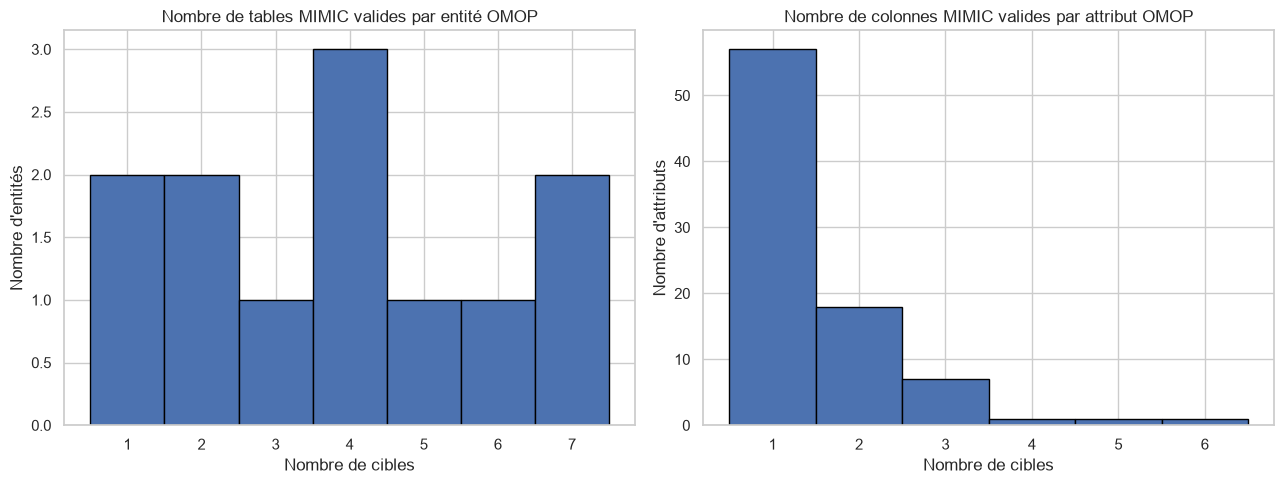

Table target cardinality:


,n_targets
omop_table_name,
drug_exposure,7
procedure_occurrence,7
observation,6
measurement,5
note,4
condition_occurrence,4
visit_detail,4
specimen,3
visit_occurrence,2


Column target cardinality:


,n_targets
omop,
observation-value_as_string,6
measurement-measurement_datetime,5
observation-observation_datetime,4
drug_exposure-drug_exposure_start_datetime,3
drug_exposure-drug_exposure_end_datetime,3
visit_occurrence-preceding_visit_occurrence_id,3
measurement-value_source_value,3
observation-observation_id,3
observation-observation_date,3


In [4]:
# ============================================================
# 2.1 Distribution du nombre de cibles par source
# ============================================================

table_targets_per_entity = (
    gold_table.groupby("omop_table_name")["mimic_table_name"]
    .nunique()
    .sort_values(ascending=False)
)

column_targets_per_source = (
    gold_column.groupby("omop")["table"]
    .nunique()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(
    table_targets_per_entity.values,
    bins=np.arange(0.5, table_targets_per_entity.max() + 1.5, 1),
    edgecolor="black"
)
axes[0].set_title("Nombre de tables MIMIC valides par entité OMOP")
axes[0].set_xlabel("Nombre de cibles")
axes[0].set_ylabel("Nombre d'entités")

axes[1].hist(
    column_targets_per_source.values,
    bins=np.arange(0.5, column_targets_per_source.max() + 1.5, 1),
    edgecolor="black"
)
axes[1].set_title("Nombre de colonnes MIMIC valides par attribut OMOP")
axes[1].set_xlabel("Nombre de cibles")
axes[1].set_ylabel("Nombre d'attributs")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_target_cardinality.png", dpi=300, bbox_inches="tight")
plt.show()

print("Table target cardinality:")
display(table_targets_per_entity.to_frame("n_targets").head(20))

print("Column target cardinality:")
display(column_targets_per_source.to_frame("n_targets").head(20))


# 3. Évaluation du mapping de tables

La vérité terrain est définie comme l'ensemble des paires :

`(OMOP entity, MIMIC table)`

présentes dans le benchmark gold.

Une prédiction est correcte si la table prédite appartient à cet ensemble de cibles valides.
Le score de confiance est ensuite transformé en décision binaire selon un seuil.


In [5]:
# ============================================================
# 3. Préparation des prédictions de tables
# ============================================================

required_table_cols = ["entity", "matched_table", "table_confidence"]
missing = [c for c in required_table_cols if c not in pred_df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes pour l'évaluation table: {missing}")

pred_table = (
    pred_df[required_table_cols]
    .dropna(subset=["entity", "matched_table", "table_confidence"])
    .copy()
)

pred_table["matched_table"] = pred_table["matched_table"].replace(TABLE_ALIASES)

# Une prédiction unique par paire entity/table.
pred_table = pred_table.drop_duplicates(
    subset=["entity", "matched_table"],
    keep="first"
).reset_index(drop=True)

gold_table_pairs = set(
    gold_table.itertuples(index=False, name=None)
)

pred_table["actual_match"] = pred_table.apply(
    lambda r: (r["entity"], r["matched_table"]) in gold_table_pairs,
    axis=1
)

print("Predicted table pairs:", len(pred_table))
print("Actual positive pairs among predictions:", pred_table["actual_match"].sum())

display(pred_table.head(10))


Predicted table pairs: 13
Actual positive pairs among predictions: 12


,entity,matched_table,table_confidence,actual_match
0,person,patients,0.9124,True
1,visit_occurrence,admissions,0.9017,True
2,visit_detail,transfers,0.8679,True
3,specimen,labevents,0.6128,True
4,measurement,labevents,0.8745,True
5,procedure_occurrence,procedures_icd,0.7936,True
6,condition_occurrence,diagnoses_icd,0.8214,True
7,death,patients,0.6842,False
8,observation,chartevents,0.7983,True
9,drug_exposure,prescriptions,0.7389,True


In [6]:
# ============================================================
# 3.1 Fonction générique d'évaluation par seuil
# ============================================================

def evaluate_thresholds(df, score_col, truth_col, thresholds):
    y_true = df[truth_col].astype(int).to_numpy()
    rows = []

    for threshold in thresholds:
        y_pred = (df[score_col] >= threshold).astype(int).to_numpy()

        tn, fp, fn, tp = confusion_matrix(
            y_true, y_pred, labels=[0, 1]
        ).ravel()

        rows.append({
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "mcc": matthews_corrcoef(y_true, y_pred),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "predicted_positive": int(y_pred.sum()),
            "actual_positive": int(y_true.sum()),
        })

    return pd.DataFrame(rows)


table_threshold_results = evaluate_thresholds(
    pred_table,
    "table_confidence",
    "actual_match",
    THRESHOLDS
)

display(
    table_threshold_results.style.format({
        c: "{:.4f}" for c in [
            "accuracy", "precision", "recall",
            "f1", "balanced_accuracy", "mcc"
        ]
    })
)

table_threshold_results.to_csv(
    TABLE_DIR / "table_threshold_results.csv",
    index=False
)


,threshold,accuracy,precision,recall,f1,balanced_accuracy,mcc,TN,FP,FN,TP,predicted_positive,actual_positive
0,0.500000,0.9231,0.9231,1.0000,0.9600,0.5000,0.0000,0,1,0,12,13,12
1,0.550000,0.8462,0.9167,0.9167,0.9167,0.4583,-0.0833,0,1,1,11,12,12
2,0.600000,0.8462,0.9167,0.9167,0.9167,0.4583,-0.0833,0,1,1,11,12,12
3,0.650000,0.6923,0.9000,0.7500,0.8182,0.3750,-0.1581,0,1,3,9,10,12
4,0.700000,0.7692,1.0000,0.7500,0.8571,0.8750,0.4330,1,0,3,9,9,12
5,0.750000,0.6923,1.0000,0.6667,0.8000,0.8333,0.3651,1,0,4,8,8,12
6,0.800000,0.5385,1.0000,0.5000,0.6667,0.7500,0.2673,1,0,6,6,6,12
7,0.850000,0.4615,1.0000,0.4167,0.5882,0.7083,0.2282,1,0,7,5,5,12
8,0.900000,0.2308,1.0000,0.1667,0.2857,0.5833,0.1231,1,0,10,2,2,12
9,0.950000,0.0769,0.0000,0.0000,0.0000,0.5000,0.0000,1,0,12,0,0,12


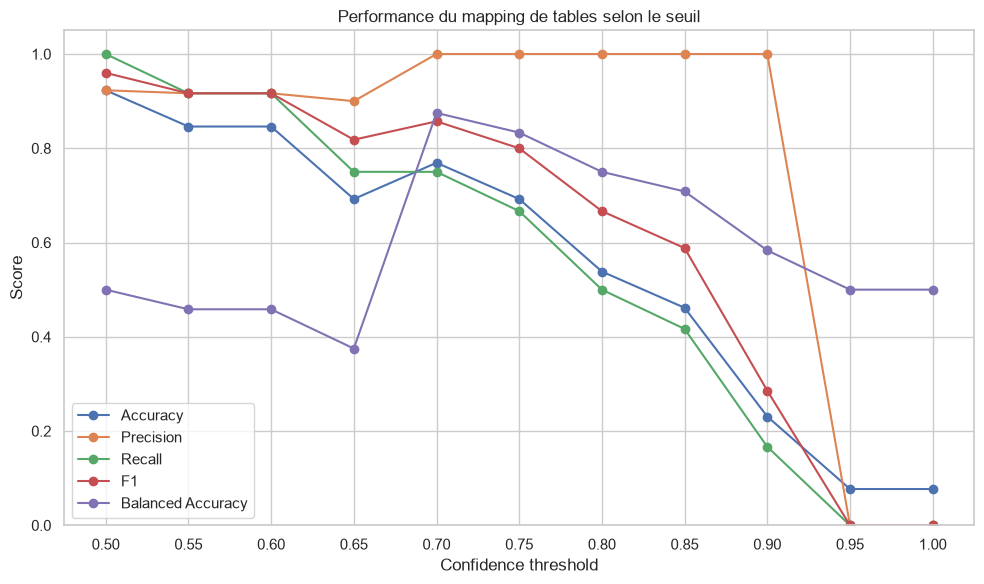

In [7]:
# ============================================================
# 3.2 Figure — Performance selon le seuil (tables)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

for metric in ["accuracy", "precision", "recall", "f1", "balanced_accuracy"]:
    ax.plot(
        table_threshold_results["threshold"],
        table_threshold_results[metric],
        marker="o",
        label=metric.replace("_", " ").title()
    )

ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Score")
ax.set_title("Performance du mapping de tables selon le seuil")
ax.set_ylim(0, 1.05)
ax.set_xticks(THRESHOLDS)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig02_table_threshold_metrics.png", dpi=300, bbox_inches="tight")
plt.show()


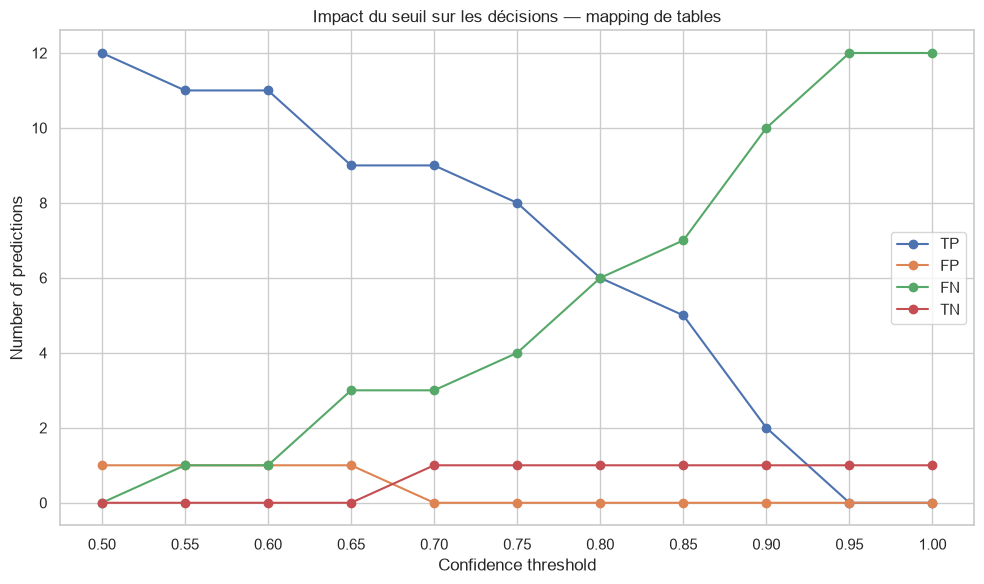

In [8]:
# ============================================================
# 3.3 Figure — TP / FP / FN / TN selon le seuil
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

for metric in ["TP", "FP", "FN", "TN"]:
    ax.plot(
        table_threshold_results["threshold"],
        table_threshold_results[metric],
        marker="o",
        label=metric
    )

ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Number of predictions")
ax.set_title("Impact du seuil sur les décisions — mapping de tables")
ax.set_xticks(THRESHOLDS)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig03_table_confusion_counts.png", dpi=300, bbox_inches="tight")
plt.show()


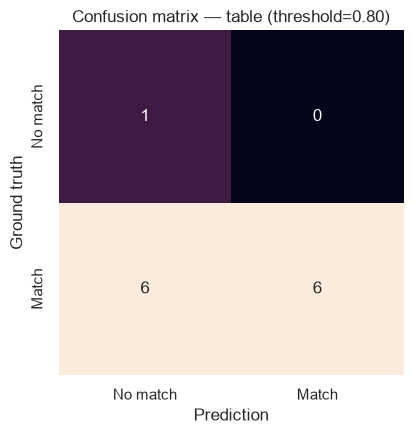

,precision,recall,f1-score,support
No match,0.142857,1.000000,0.250000,1.000000
Match,1.000000,0.500000,0.666667,12.000000
accuracy,0.538462,0.538462,0.538462,0.538462
macro avg,0.571429,0.750000,0.458333,13.000000
weighted avg,0.934066,0.538462,0.634615,13.000000


In [9]:
# ============================================================
# 3.4 Matrice de confusion au seuil de référence 0.80
# ============================================================

TABLE_THRESHOLD = 0.80

pred_table["label_080"] = (
    pred_table["table_confidence"] >= TABLE_THRESHOLD
).astype(int)

cm_table = confusion_matrix(
    pred_table["actual_match"].astype(int),
    pred_table["label_080"],
    labels=[0, 1]
)

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(
    cm_table,
    annot=True,
    fmt="d",
    square=True,
    cbar=False,
    xticklabels=["No match", "Match"],
    yticklabels=["No match", "Match"],
    ax=ax
)
ax.set_xlabel("Prediction")
ax.set_ylabel("Ground truth")
ax.set_title(f"Confusion matrix — table (threshold={TABLE_THRESHOLD:.2f})")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig04_table_confusion_matrix_080.png", dpi=300, bbox_inches="tight")
plt.show()

table_report_080 = pd.DataFrame(
    classification_report(
        pred_table["actual_match"].astype(int),
        pred_table["label_080"],
        target_names=["No match", "Match"],
        zero_division=0,
        output_dict=True
    )
).T

display(table_report_080)
table_report_080.to_csv(TABLE_DIR / "table_classification_report_080.csv")


In [10]:
def select_best_thresholds(results):
    best_f1 = results.loc[results["f1"].idxmax()].copy()
    best_bal = results.loc[results["balanced_accuracy"].idxmax()].copy()
    best_mcc = results.loc[results["mcc"].idxmax()].copy()

    best_f1["selection_rule"] = "Maximum F1"
    best_bal["selection_rule"] = "Maximum Balanced Accuracy"
    best_mcc["selection_rule"] = "Maximum MCC"

    return pd.DataFrame([
        best_f1,
        best_bal,
        best_mcc
    ])
best_thresholds = select_best_thresholds(table_threshold_results)

display(best_thresholds)

,threshold,accuracy,precision,recall,f1,balanced_accuracy,mcc,TN,FP,FN,TP,predicted_positive,actual_positive,selection_rule
0,0.5,0.923077,0.923077,1.00,0.960000,0.500,0.000000,0.0,1.0,0.0,12.0,13.0,12.0,Maximum F1
4,0.7,0.769231,1.000000,0.75,0.857143,0.875,0.433013,1.0,0.0,3.0,9.0,9.0,12.0,Maximum Balanced Accuracy
4,0.7,0.769231,1.000000,0.75,0.857143,0.875,0.433013,1.0,0.0,3.0,9.0,9.0,12.0,Maximum MCC


## 4. Analyse de la séparation des scores — tables

Une bonne métrique de confiance doit idéalement attribuer des scores plus élevés aux vrais matches qu'aux faux matches.

Deux indicateurs complémentaires sont donc rapportés :

- **ROC-AUC** : capacité globale de classement ;
- **Average Precision (AP)** : particulièrement informative lorsque la classe positive est minoritaire.

Ces mesures sont indépendantes d'un seuil particulier.


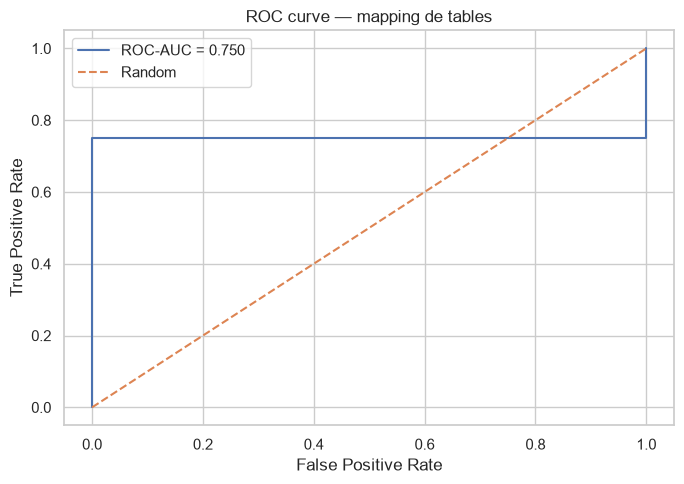

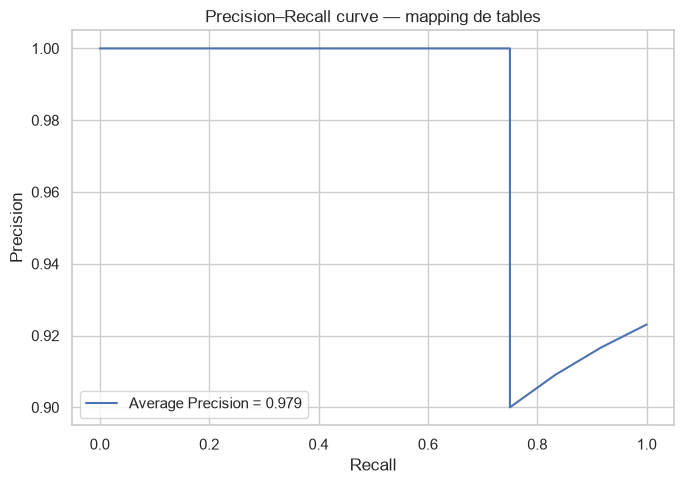

Table ROC-AUC = 0.7500
Table Average Precision = 0.9791


In [11]:
# ============================================================
# 4.1 ROC et Precision-Recall — tables
# ============================================================

y_true_t = pred_table["actual_match"].astype(int).to_numpy()
scores_t = pred_table["table_confidence"].astype(float).to_numpy()

if len(np.unique(y_true_t)) == 2:
    roc_auc_t = roc_auc_score(y_true_t, scores_t)
    ap_t = average_precision_score(y_true_t, scores_t)

    fpr_t, tpr_t, _ = roc_curve(y_true_t, scores_t)
    precision_t, recall_t, _ = precision_recall_curve(y_true_t, scores_t)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr_t, tpr_t, label=f"ROC-AUC = {roc_auc_t:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC curve — mapping de tables")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig05_table_roc.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(recall_t, precision_t, label=f"Average Precision = {ap_t:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision–Recall curve — mapping de tables")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig06_table_pr.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Table ROC-AUC = {roc_auc_t:.4f}")
    print(f"Table Average Precision = {ap_t:.4f}")
else:
    print("ROC-AUC/AP non calculables : une seule classe est présente.")


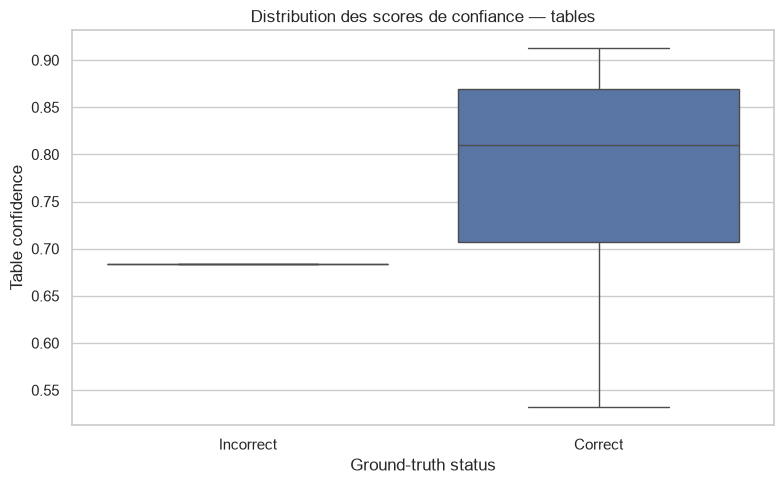

In [12]:
# ============================================================
# 4.2 Distribution des scores — tables
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=pred_table,
    x="actual_match",
    y="table_confidence",
    ax=ax
)

ax.set_xticklabels(["Incorrect", "Correct"])
ax.set_xlabel("Ground-truth status")
ax.set_ylabel("Table confidence")
ax.set_title("Distribution des scores de confiance — tables")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig07_table_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


# 5. Évaluation du mapping de colonnes

Pour les colonnes, la vérité terrain est construite à partir de :

`source_key → {target_key_1, target_key_2, ...}`

Une prédiction est considérée correcte si `target_key` appartient à l'ensemble des cibles gold associées à son `source_key`.


In [13]:
# ============================================================
# 5. Préparation des prédictions de colonnes
# ============================================================

required_col_cols = ["entity", "attribute", "source_key", "target_key", "confidence"]
missing = [c for c in required_col_cols if c not in pred_df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes pour l'évaluation colonne: {missing}")

gold_column_map = (
    data_positive.groupby("omop")["table"]
    .apply(set)
    .to_dict()
)

pred_column = (
    pred_df[required_col_cols]
    .dropna(subset=["source_key", "target_key", "confidence"])
    .drop_duplicates(subset=["source_key", "target_key"])
    .copy()
)

def is_actual_column_match(row):
    targets = gold_column_map.get(row["source_key"])
    return False if targets is None else row["target_key"] in targets

pred_column["actual_match"] = pred_column.apply(
    is_actual_column_match,
    axis=1
)

print("Predicted column pairs:", len(pred_column))
print("Actual positive pairs among predictions:", pred_column["actual_match"].sum())

display(pred_column.head(10))


Predicted column pairs: 94
Actual positive pairs among predictions: 37


,entity,attribute,source_key,target_key,confidence,actual_match
0,person,birth_datetime,person-birth_datetime,patients-dob,0.9341,True
2,person,day_of_birth,person-day_of_birth,patients-dob,0.9012,True
3,person,death_datetime,person-death_datetime,patients-dod,0.9478,True
6,person,ethnicity_source_value,person-ethnicity_source_value,patients-ethnicity,0.7823,False
7,person,gender_concept_id,person-gender_concept_id,patients-gender,0.9687,True
9,person,gender_source_value,person-gender_source_value,patients-gender,0.9554,True
11,person,month_of_birth,person-month_of_birth,patients-dob,0.8889,True
12,person,person_id,person-person_id,patients-subject_id,0.9912,False
17,person,race_source_value,person-race_source_value,patients-ethnicity,0.5126,False
18,person,year_of_birth,person-year_of_birth,patients-dob,0.8765,True


In [14]:
# ============================================================
# 5.1 Évaluation de tous les seuils — colonnes
# ============================================================

column_threshold_results = evaluate_thresholds(
    pred_column,
    "confidence",
    "actual_match",
    THRESHOLDS
)

display(
    column_threshold_results.style.format({
        c: "{:.4f}" for c in [
            "accuracy", "precision", "recall",
            "f1", "balanced_accuracy", "mcc"
        ]
    })
)

column_threshold_results.to_csv(
    TABLE_DIR / "column_threshold_results.csv",
    index=False
)


,threshold,accuracy,precision,recall,f1,balanced_accuracy,mcc,TN,FP,FN,TP,predicted_positive,actual_positive
0,0.500000,0.4043,0.3978,1.0000,0.5692,0.5088,0.0835,1,56,0,37,93,37
1,0.550000,0.4149,0.4022,1.0000,0.5736,0.5175,0.1188,2,55,0,37,92,37
2,0.600000,0.4149,0.4022,1.0000,0.5736,0.5175,0.1188,2,55,0,37,92,37
3,0.650000,0.4149,0.4022,1.0000,0.5736,0.5175,0.1188,2,55,0,37,92,37
4,0.700000,0.4362,0.4111,1.0000,0.5827,0.5351,0.1699,4,53,0,37,90,37
5,0.750000,0.5000,0.4405,1.0000,0.6116,0.5877,0.2780,10,47,0,37,84,37
6,0.800000,0.5745,0.4805,1.0000,0.6491,0.6491,0.3786,17,40,0,37,77,37
7,0.850000,0.5745,0.4776,0.8649,0.6154,0.6254,0.2708,22,35,5,32,67,37
8,0.900000,0.6915,0.6000,0.6486,0.6234,0.6840,0.3636,41,16,13,24,40,37
9,0.950000,0.6277,0.6000,0.1622,0.2553,0.5460,0.1458,53,4,31,6,10,37


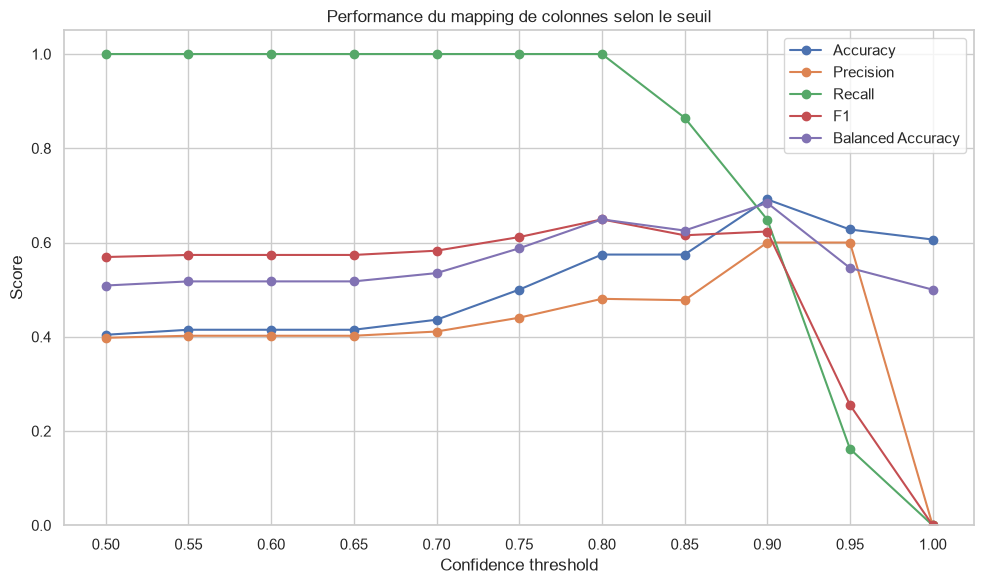

In [15]:
# ============================================================
# 5.2 Figure — Performance selon le seuil (colonnes)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

for metric in ["accuracy", "precision", "recall", "f1", "balanced_accuracy"]:
    ax.plot(
        column_threshold_results["threshold"],
        column_threshold_results[metric],
        marker="o",
        label=metric.replace("_", " ").title()
    )

ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Score")
ax.set_title("Performance du mapping de colonnes selon le seuil")
ax.set_ylim(0, 1.05)
ax.set_xticks(THRESHOLDS)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig08_column_threshold_metrics.png", dpi=300, bbox_inches="tight")
plt.show()


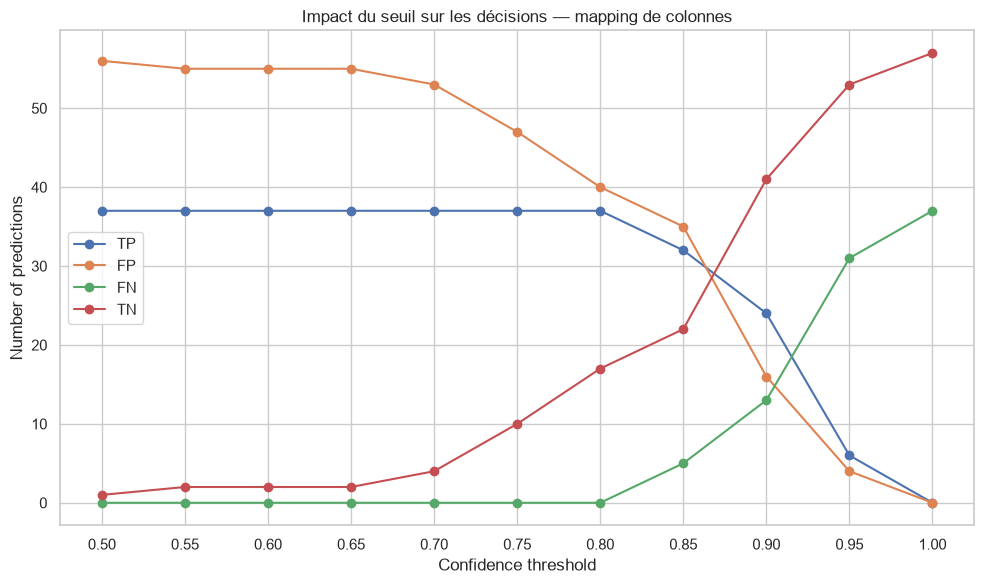

In [16]:
# ============================================================
# 5.3 Figure — TP / FP / FN / TN selon le seuil
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

for metric in ["TP", "FP", "FN", "TN"]:
    ax.plot(
        column_threshold_results["threshold"],
        column_threshold_results[metric],
        marker="o",
        label=metric
    )

ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Number of predictions")
ax.set_title("Impact du seuil sur les décisions — mapping de colonnes")
ax.set_xticks(THRESHOLDS)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig09_column_confusion_counts.png", dpi=300, bbox_inches="tight")
plt.show()


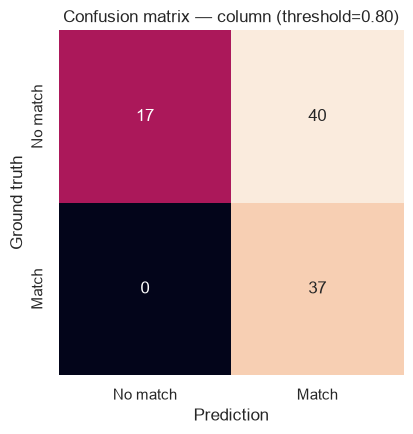

Threshold = 0.80


,precision,recall,f1-score,support
No match,1.000000,0.298246,0.459459,57.000000
Match,0.480519,1.000000,0.649123,37.000000
accuracy,0.574468,0.574468,0.574468,0.574468
macro avg,0.740260,0.649123,0.554291,94.000000
weighted avg,0.795524,0.574468,0.534114,94.000000


In [17]:
# ============================================================
# 5.4 Matrices de confusion — colonnes, 0.80 et meilleur F1
# ============================================================

COLUMN_THRESHOLD_REFERENCE = 0.80
best_column_f1_threshold = float(
    column_threshold_results.loc[
        column_threshold_results["f1"].idxmax(), "threshold"
    ]
)

selected_column_thresholds = sorted(
    set([COLUMN_THRESHOLD_REFERENCE, best_column_f1_threshold])
)

for threshold in selected_column_thresholds:
    y_pred = (
        pred_column["confidence"] >= threshold
    ).astype(int)

    cm = confusion_matrix(
        pred_column["actual_match"].astype(int),
        y_pred,
        labels=[0, 1]
    )

    fig, ax = plt.subplots(figsize=(5, 4.5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        square=True,
        cbar=False,
        xticklabels=["No match", "Match"],
        yticklabels=["No match", "Match"],
        ax=ax
    )
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Ground truth")
    ax.set_title(f"Confusion matrix — column (threshold={threshold:.2f})")
    plt.tight_layout()
    suffix = str(threshold).replace(".", "")
    plt.savefig(
        FIG_DIR / f"fig10_column_confusion_matrix_{suffix}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    report = pd.DataFrame(
        classification_report(
            pred_column["actual_match"].astype(int),
            y_pred,
            target_names=["No match", "Match"],
            zero_division=0,
            output_dict=True
        )
    ).T

    print(f"Threshold = {threshold:.2f}")
    display(report)


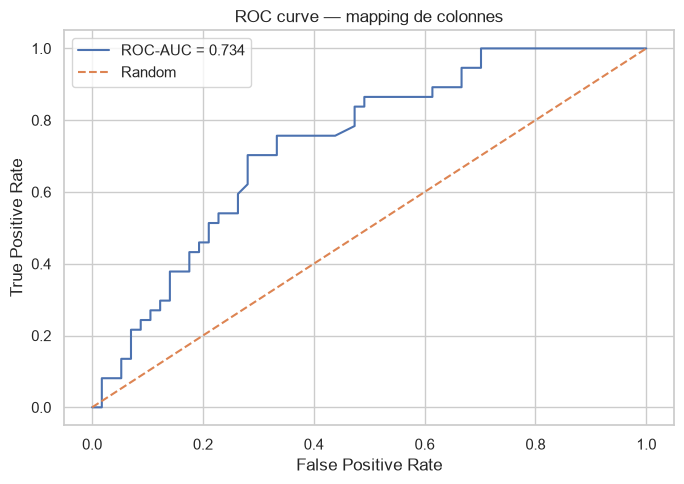

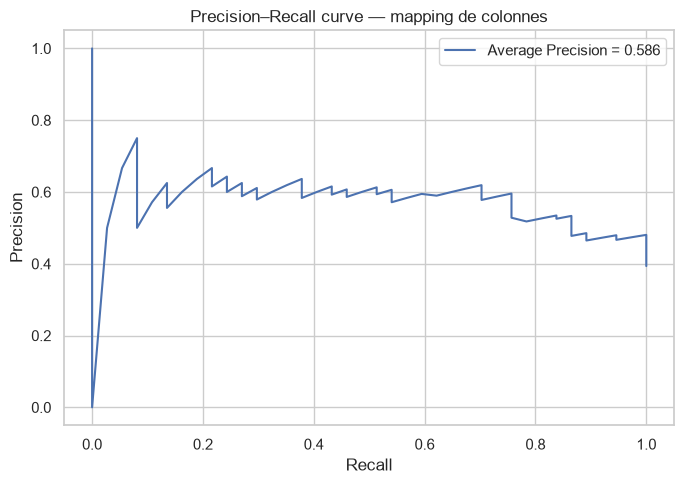

Column ROC-AUC = 0.7338
Column Average Precision = 0.5858


In [18]:
# ============================================================
# 5.5 ROC et Precision-Recall — colonnes
# ============================================================

y_true_c = pred_column["actual_match"].astype(int).to_numpy()
scores_c = pred_column["confidence"].astype(float).to_numpy()

if len(np.unique(y_true_c)) == 2:
    roc_auc_c = roc_auc_score(y_true_c, scores_c)
    ap_c = average_precision_score(y_true_c, scores_c)

    fpr_c, tpr_c, _ = roc_curve(y_true_c, scores_c)
    precision_c, recall_c, _ = precision_recall_curve(y_true_c, scores_c)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr_c, tpr_c, label=f"ROC-AUC = {roc_auc_c:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC curve — mapping de colonnes")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig11_column_roc.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(recall_c, precision_c, label=f"Average Precision = {ap_c:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision–Recall curve — mapping de colonnes")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig12_column_pr.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Column ROC-AUC = {roc_auc_c:.4f}")
    print(f"Column Average Precision = {ap_c:.4f}")
else:
    print("ROC-AUC/AP non calculables : une seule classe est présente.")


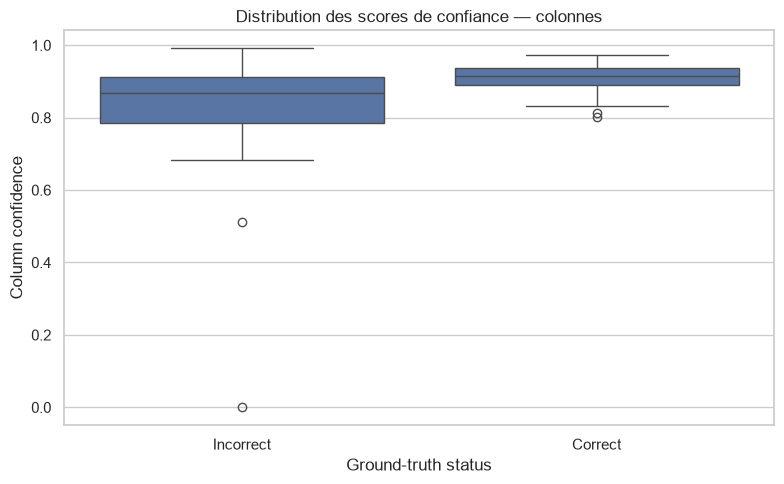

In [19]:
# ============================================================
# 5.6 Distribution des scores — colonnes
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=pred_column,
    x="actual_match",
    y="confidence",
    ax=ax
)

ax.set_xticklabels(["Incorrect", "Correct"])
ax.set_xlabel("Ground-truth status")
ax.set_ylabel("Column confidence")
ax.set_title("Distribution des scores de confiance — colonnes")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig13_column_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


# 6. Analyse par entité

Une performance globale peut masquer de fortes différences entre les entités OMOP.

On rapporte donc, pour chaque entité :

- nombre de prédictions ;
- nombre de matches corrects ;
- précision empirique ;
- taux de couverture des matches gold observés dans les prédictions ;
- confiance moyenne.

Cette vue est particulièrement utile pour identifier les concepts difficiles.


,predictions,correct,mean_confidence,precision,gold_targets
entity,,,,,
death,1,0,0.6842,0.0,0.0
care_site,1,1,0.5318,1.0,1.0
condition_occurrence,1,1,0.8214,1.0,4.0
drug_exposure,1,1,0.7389,1.0,7.0
measurement,1,1,0.8745,1.0,5.0
note,1,1,0.8517,1.0,4.0
observation,1,1,0.7983,1.0,6.0
person,1,1,0.9124,1.0,2.0
procedure_occurrence,1,1,0.7936,1.0,7.0


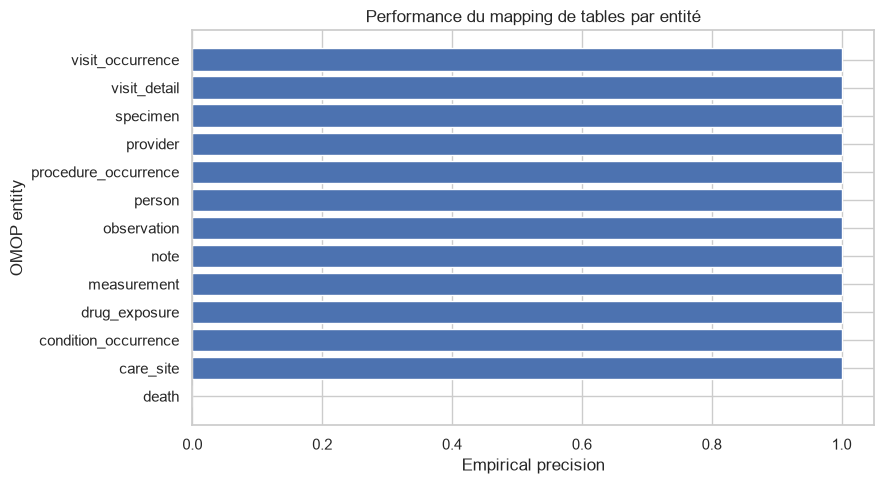

In [20]:
# ============================================================
# 6.1 Analyse par entité — tables
# ============================================================

def per_entity_table_analysis(pred_table, gold_table):
    gold_counts = (
        gold_table.groupby("omop_table_name")["mimic_table_name"]
        .nunique()
        .rename("gold_targets")
    )

    pred_counts = (
        pred_table.groupby("entity")
        .agg(
            predictions=("matched_table", "count"),
            correct=("actual_match", "sum"),
            mean_confidence=("table_confidence", "mean"),
        )
    )

    pred_counts["precision"] = (
        pred_counts["correct"] / pred_counts["predictions"]
    )

    pred_counts = pred_counts.join(
        gold_counts,
        how="left"
    )

    pred_counts["gold_targets"] = pred_counts["gold_targets"].fillna(0)

    return pred_counts.sort_values("precision")

per_entity_table = per_entity_table_analysis(
    pred_table, gold_table
)

display(per_entity_table)

per_entity_table.to_csv(
    TABLE_DIR / "per_entity_table_results.csv"
)

fig, ax = plt.subplots(figsize=(9, max(5, len(per_entity_table) * 0.35)))

plot_df = per_entity_table.sort_values("precision")

ax.barh(
    plot_df.index.astype(str),
    plot_df["precision"]
)

ax.set_xlim(0, 1.05)
ax.set_xlabel("Empirical precision")
ax.set_ylabel("OMOP entity")
ax.set_title("Performance du mapping de tables par entité")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig14_table_per_entity.png", dpi=300, bbox_inches="tight")
plt.show()


,predictions,correct,mean_confidence,precision,error_rate
entity,,,,,
care_site,3,0,0.824533,0.000000,1.000000
condition_occurrence,6,0,0.820950,0.000000,1.000000
death,3,0,0.938267,0.000000,1.000000
procedure_occurrence,6,0,0.681817,0.000000,1.000000
observation,10,3,0.875320,0.300000,0.700000
drug_exposure,12,4,0.814808,0.333333,0.666667
measurement,9,3,0.897733,0.333333,0.666667
specimen,4,2,0.851825,0.500000,0.500000
visit_detail,10,5,0.888730,0.500000,0.500000


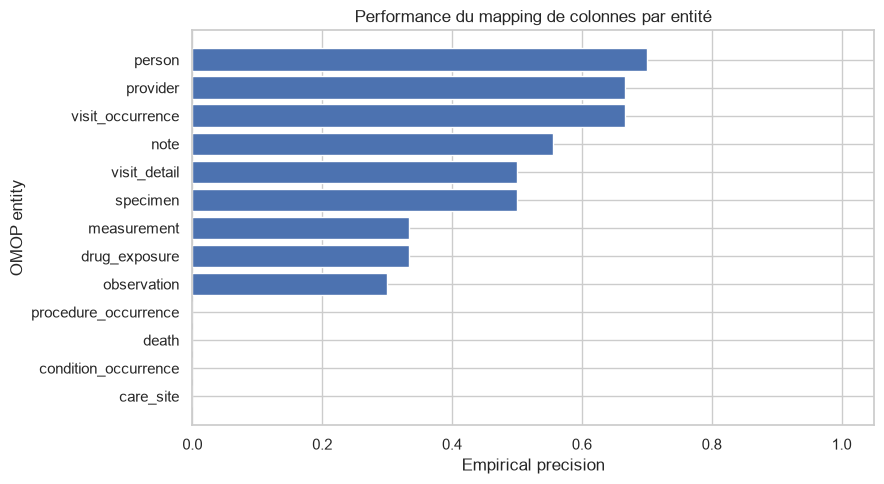

In [21]:
# ============================================================
# 6.2 Analyse par entité — colonnes
# ============================================================

per_entity_column = (
    pred_column.groupby("entity")
    .agg(
        predictions=("source_key", "count"),
        correct=("actual_match", "sum"),
        mean_confidence=("confidence", "mean"),
    )
)

per_entity_column["precision"] = (
    per_entity_column["correct"] /
    per_entity_column["predictions"]
)

per_entity_column["error_rate"] = (
    1 - per_entity_column["precision"]
)

per_entity_column = per_entity_column.sort_values("precision")

display(per_entity_column)
per_entity_column.to_csv(
    TABLE_DIR / "per_entity_column_results.csv"
)

fig, ax = plt.subplots(figsize=(9, max(5, len(per_entity_column) * 0.35)))

plot_df = per_entity_column.sort_values("precision")

ax.barh(
    plot_df.index.astype(str),
    plot_df["precision"]
)

ax.set_xlim(0, 1.05)
ax.set_xlabel("Empirical precision")
ax.set_ylabel("OMOP entity")
ax.set_title("Performance du mapping de colonnes par entité")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig15_column_per_entity.png", dpi=300, bbox_inches="tight")
plt.show()


# 7. Analyse des erreurs

Pour l'article, il est recommandé de rapporter non seulement une métrique agrégée, mais également quelques exemples représentatifs de :

- **False Positives** : score élevé mais correspondance incorrecte ;
- **False Negatives** : correspondance gold mais score inférieur au seuil ;
- cas proches de la frontière de décision.

Ces tableaux permettent d'analyser qualitativement les limites du système.


In [22]:
# ============================================================
# 7.1 Erreurs — tables au seuil 0.80
# ============================================================

pred_table_errors = pred_table.copy()

pred_table_errors["prediction_080"] = (
    pred_table_errors["table_confidence"] >= TABLE_THRESHOLD
).astype(int)

table_fp = (
    pred_table_errors[
        (pred_table_errors["prediction_080"] == 1) &
        (~pred_table_errors["actual_match"])
    ]
    .sort_values("table_confidence", ascending=False)
)

table_fn = (
    pred_table_errors[
        (pred_table_errors["prediction_080"] == 0) &
        (pred_table_errors["actual_match"])
    ]
    .sort_values("table_confidence", ascending=False)
)

print("Top False Positives — tables")
display(table_fp.head(20))

print("Top False Negatives — tables")
display(table_fn.head(20))

table_fp.head(50).to_csv(TABLE_DIR / "table_false_positives.csv", index=False)
table_fn.head(50).to_csv(TABLE_DIR / "table_false_negatives.csv", index=False)


Top False Positives — tables


,entity,matched_table,table_confidence,actual_match,label_080,prediction_080


Top False Negatives — tables


,entity,matched_table,table_confidence,actual_match,label_080,prediction_080
8,observation,chartevents,0.7983,True,0,0
5,procedure_occurrence,procedures_icd,0.7936,True,0,0
9,drug_exposure,prescriptions,0.7389,True,0,0
3,specimen,labevents,0.6128,True,0,0
12,provider,caregivers,0.6124,True,0,0
11,care_site,transfers,0.5318,True,0,0


In [23]:
# ============================================================
# 7.2 Erreurs — colonnes au seuil optimal F1
# ============================================================

pred_column_errors = pred_column.copy()

pred_column_errors["prediction_selected"] = (
    pred_column_errors["confidence"] >= best_column_f1_threshold
).astype(int)

column_fp = (
    pred_column_errors[
        (pred_column_errors["prediction_selected"] == 1) &
        (~pred_column_errors["actual_match"])
    ]
    .sort_values("confidence", ascending=False)
)

column_fn = (
    pred_column_errors[
        (pred_column_errors["prediction_selected"] == 0) &
        (pred_column_errors["actual_match"])
    ]
    .sort_values("confidence", ascending=False)
)

print(f"Selected column threshold = {best_column_f1_threshold:.2f}")
print("Top False Positives — columns")
display(column_fp.head(30))

print("Top False Negatives — columns")
display(column_fn.head(30))

column_fp.head(50).to_csv(TABLE_DIR / "column_false_positives.csv", index=False)
column_fn.head(50).to_csv(TABLE_DIR / "column_false_negatives.csv", index=False)


Selected column threshold = 0.80
Top False Positives — columns


,entity,attribute,source_key,target_key,confidence,actual_match,prediction_selected
12,person,person_id,person-person_id,patients-subject_id,0.9912,False,1
126,death,person_id,death-person_id,patients-subject_id,0.9673,False,1
30,visit_occurrence,visit_occurrence_id,visit_occurrence-visit_occurrence_id,admissions-hadm_id,0.9583,False,1
86,measurement,value_as_number,measurement-value_as_number,labevents-valuenum,0.9531,False,1
24,visit_occurrence,person_id,visit_occurrence-person_id,admissions-subject_id,0.9448,False,1
41,visit_detail,person_id,visit_detail-person_id,transfers-subject_id,0.9387,False,1
124,death,death_datetime,death-death_datetime,patients-dod,0.9348,False,1
79,measurement,person_id,measurement-person_id,labevents-subject_id,0.9318,False,1
144,observation,person_id,observation-person_id,chartevents-subject_id,0.9257,False,1
71,measurement,measurement_date,measurement-measurement_date,labevents-charttime,0.9256,False,1


Top False Negatives — columns


,entity,attribute,source_key,target_key,confidence,actual_match,prediction_selected


In [24]:
# ============================================================
# 7.3 Cas proches de la frontière de décision
# ============================================================

MARGIN = 0.05

table_boundary = (
    pred_table.assign(
        distance_to_threshold=lambda x:
            (x["table_confidence"] - TABLE_THRESHOLD).abs()
    )
    .sort_values("distance_to_threshold")
    .head(30)
)

column_boundary = (
    pred_column.assign(
        distance_to_threshold=lambda x:
            (x["confidence"] - best_column_f1_threshold).abs()
    )
    .sort_values("distance_to_threshold")
    .head(30)
)

print("Table boundary cases")
display(table_boundary)

print("Column boundary cases")
display(column_boundary)

table_boundary.to_csv(TABLE_DIR / "table_boundary_cases.csv", index=False)
column_boundary.to_csv(TABLE_DIR / "column_boundary_cases.csv", index=False)


Table boundary cases


,entity,matched_table,table_confidence,actual_match,label_080,distance_to_threshold
8,observation,chartevents,0.7983,True,0,0.0017
5,procedure_occurrence,procedures_icd,0.7936,True,0,0.0064
6,condition_occurrence,diagnoses_icd,0.8214,True,1,0.0214
10,note,noteevents,0.8517,True,1,0.0517
9,drug_exposure,prescriptions,0.7389,True,0,0.0611
2,visit_detail,transfers,0.8679,True,1,0.0679
4,measurement,labevents,0.8745,True,1,0.0745
1,visit_occurrence,admissions,0.9017,True,1,0.1017
0,person,patients,0.9124,True,1,0.1124
7,death,patients,0.6842,False,0,0.1158


Column boundary cases


,entity,attribute,source_key,target_key,confidence,actual_match,distance_to_threshold
168,drug_exposure,drug_exposure_start_datetime,drug_exposure-drug_exposure_start_datetime,prescriptions-startdate,0.8015,True,0.0015
96,procedure_occurrence,procedure_occurrence_id,procedure_occurrence-procedure_occurrence_id,procedures_icd-row_id,0.7943,False,0.0057
166,drug_exposure,drug_exposure_id,drug_exposure-drug_exposure_id,prescriptions-row_id,0.7938,False,0.0062
164,drug_exposure,drug_exposure_end_date,drug_exposure-drug_exposure_end_date,prescriptions-enddate,0.8126,True,0.0126
73,measurement,measurement_id,measurement-measurement_id,labevents-row_id,0.8127,False,0.0127
162,drug_exposure,dose_unit_source_value,drug_exposure-dose_unit_source_value,prescriptions-dose_unit_rx,0.7842,False,0.0158
6,person,ethnicity_source_value,person-ethnicity_source_value,patients-ethnicity,0.7823,False,0.0177
89,measurement,visit_occurrence_id,measurement-visit_occurrence_id,labevents-hadm_id,0.8294,False,0.0294
262,provider,provider_source_value,provider-provider_source_value,caregivers-label,0.8317,True,0.0317
167,drug_exposure,drug_exposure_start_date,drug_exposure-drug_exposure_start_date,prescriptions-startdate,0.8347,True,0.0347


# 8. Comparaison synthétique table vs colonne

Cette section produit les tableaux principaux susceptibles d'être repris dans la section **Experimental Results** de l'article.

Deux niveaux doivent être distingués :

- **performance à seuil fixe** : par exemple 0.80 ;
- **performance au seuil sélectionné** : par exemple maximum F1.

Le second est utile pour étudier la calibration ; le premier permet une comparaison reproductible avec une politique de décision donnée.


In [25]:
# ============================================================
# 8.1 Tableau synthétique à seuils de référence
# ============================================================

def metrics_at_threshold(df, score_col, truth_col, threshold, level):
    y_true = df[truth_col].astype(int)
    y_pred = (df[score_col] >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    return {
        "Level": level,
        "Threshold": threshold,
        "N": len(df),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }

reference_summary = pd.DataFrame([
    metrics_at_threshold(
        pred_table, "table_confidence", "actual_match",
        TABLE_THRESHOLD, "Table"
    ),
    metrics_at_threshold(
        pred_column, "confidence", "actual_match",
        COLUMN_THRESHOLD_REFERENCE, "Column"
    ),
    metrics_at_threshold(
        pred_column, "confidence", "actual_match",
        best_column_f1_threshold, "Column (best F1)"
    ),
])

display(
    reference_summary.style.format({
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "Accuracy": "{:.3f}",
        "Balanced Accuracy": "{:.3f}",
        "MCC": "{:.3f}",
        "Threshold": "{:.2f}",
    })
)

reference_summary.to_csv(
    TABLE_DIR / "summary_reference_thresholds.csv",
    index=False
)


,Level,Threshold,N,TP,FP,FN,TN,Precision,Recall,F1,Accuracy,Balanced Accuracy,MCC
0,Table,0.80,13,6,0,6,1,1.000,0.500,0.667,0.538,0.750,0.267
1,Column,0.80,94,37,40,0,17,0.481,1.000,0.649,0.574,0.649,0.379
2,Column (best F1),0.80,94,37,40,0,17,0.481,1.000,0.649,0.574,0.649,0.379


In [26]:
# ============================================================
# 8.2 Meilleur seuil selon F1
# ============================================================

best_table_f1 = table_threshold_results.loc[
    table_threshold_results["f1"].idxmax()
]

best_column_f1 = column_threshold_results.loc[
    column_threshold_results["f1"].idxmax()
]

best_threshold_summary = pd.DataFrame([
    {
        "Level": "Table",
        "Selection": "Maximum F1",
        **best_table_f1.to_dict()
    },
    {
        "Level": "Column",
        "Selection": "Maximum F1",
        **best_column_f1.to_dict()
    }
])

display(
    best_threshold_summary.style.format({
        "threshold": "{:.2f}",
        "accuracy": "{:.4f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "mcc": "{:.4f}",
    })
)

best_threshold_summary.to_csv(
    TABLE_DIR / "best_threshold_summary.csv",
    index=False
)


,Level,Selection,threshold,accuracy,precision,recall,f1,balanced_accuracy,mcc,TN,FP,FN,TP,predicted_positive,actual_positive
0,Table,Maximum F1,0.50,0.9231,0.9231,1.0000,0.9600,0.5000,0.0000,0.000000,1.000000,0.000000,12.000000,13.000000,12.000000
1,Column,Maximum F1,0.80,0.5745,0.4805,1.0000,0.6491,0.6491,0.3786,17.000000,40.000000,0.000000,37.000000,77.000000,37.000000


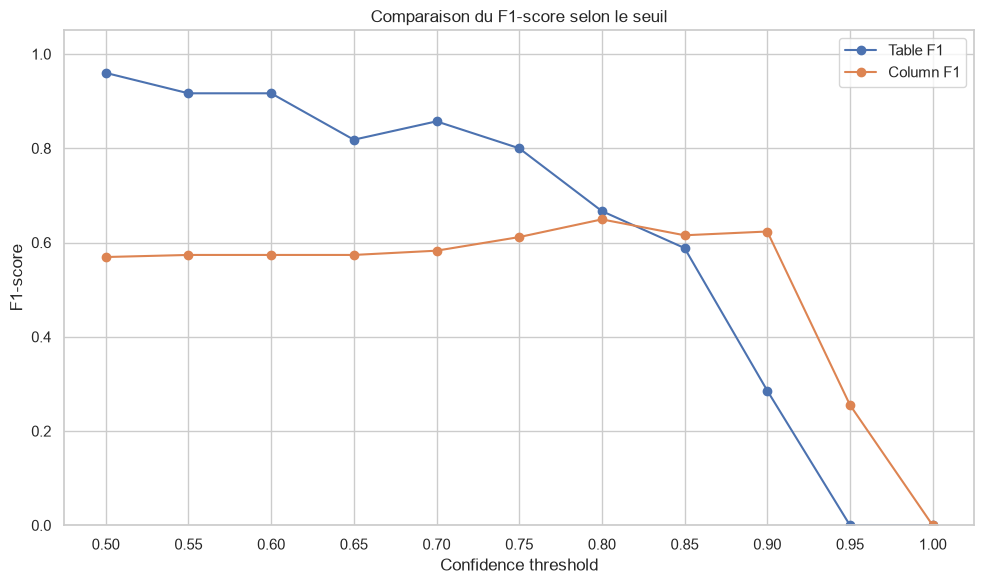

In [27]:
# ============================================================
# 8.3 Figure comparative — F1 table vs colonne
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    table_threshold_results["threshold"],
    table_threshold_results["f1"],
    marker="o",
    label="Table F1"
)

ax.plot(
    column_threshold_results["threshold"],
    column_threshold_results["f1"],
    marker="o",
    label="Column F1"
)

ax.set_xlabel("Confidence threshold")
ax.set_ylabel("F1-score")
ax.set_title("Comparaison du F1-score selon le seuil")
ax.set_ylim(0, 1.05)
ax.set_xticks(THRESHOLDS)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig16_table_vs_column_f1.png", dpi=300, bbox_inches="tight")
plt.show()


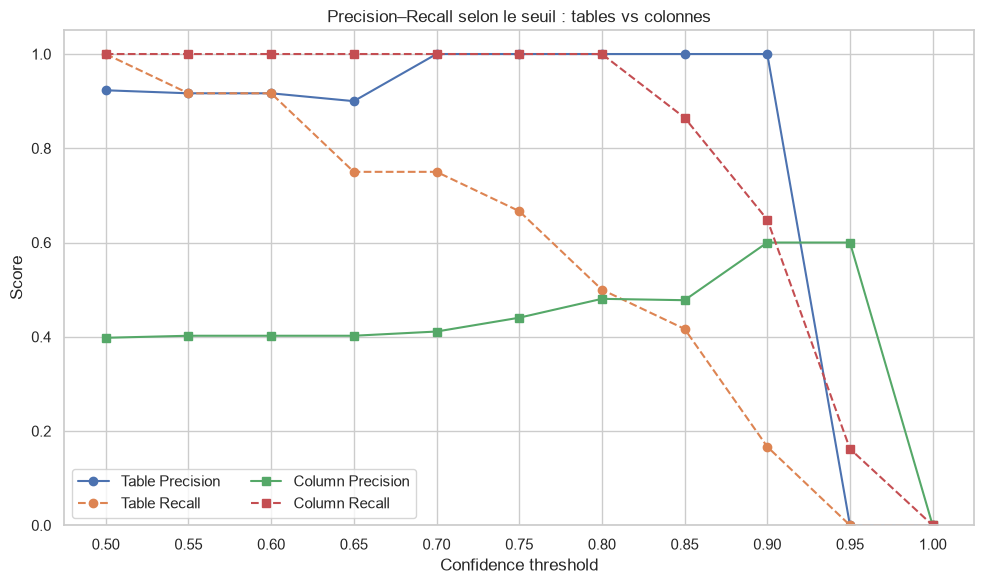

In [28]:
# ============================================================
# 8.4 Figure comparative — Precision / Recall
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    table_threshold_results["threshold"],
    table_threshold_results["precision"],
    marker="o",
    label="Table Precision"
)

ax.plot(
    table_threshold_results["threshold"],
    table_threshold_results["recall"],
    marker="o",
    linestyle="--",
    label="Table Recall"
)

ax.plot(
    column_threshold_results["threshold"],
    column_threshold_results["precision"],
    marker="s",
    label="Column Precision"
)

ax.plot(
    column_threshold_results["threshold"],
    column_threshold_results["recall"],
    marker="s",
    linestyle="--",
    label="Column Recall"
)

ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Score")
ax.set_title("Precision–Recall selon le seuil : tables vs colonnes")
ax.set_ylim(0, 1.05)
ax.set_xticks(THRESHOLDS)
ax.legend(ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig17_precision_recall_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# 9. Tableau complet des seuils

Le tableau suivant est destiné à l'analyse expérimentale détaillée et peut être exporté comme tableau supplémentaire (*supplementary material*).

Il permet de justifier objectivement le seuil retenu au lieu de sélectionner arbitrairement 0.80.


In [29]:
# ============================================================
# 9. Tableau combiné de tous les seuils
# ============================================================

table_all = table_threshold_results.copy()
table_all.insert(0, "Level", "Table")

column_all = column_threshold_results.copy()
column_all.insert(0, "Level", "Column")

all_threshold_results = pd.concat(
    [table_all, column_all],
    ignore_index=True
)

display(all_threshold_results)

all_threshold_results.to_csv(
    TABLE_DIR / "all_threshold_results.csv",
    index=False
)


,Level,threshold,accuracy,precision,recall,f1,balanced_accuracy,mcc,TN,FP,FN,TP,predicted_positive,actual_positive
0,Table,0.50,0.923077,0.923077,1.000000,0.960000,0.500000,0.000000,0,1,0,12,13,12
1,Table,0.55,0.846154,0.916667,0.916667,0.916667,0.458333,-0.083333,0,1,1,11,12,12
2,Table,0.60,0.846154,0.916667,0.916667,0.916667,0.458333,-0.083333,0,1,1,11,12,12
3,Table,0.65,0.692308,0.900000,0.750000,0.818182,0.375000,-0.158114,0,1,3,9,10,12
4,Table,0.70,0.769231,1.000000,0.750000,0.857143,0.875000,0.433013,1,0,3,9,9,12
5,Table,0.75,0.692308,1.000000,0.666667,0.800000,0.833333,0.365148,1,0,4,8,8,12
6,Table,0.80,0.538462,1.000000,0.500000,0.666667,0.750000,0.267261,1,0,6,6,6,12
7,Table,0.85,0.461538,1.000000,0.416667,0.588235,0.708333,0.228218,1,0,7,5,5,12
8,Table,0.90,0.230769,1.000000,0.166667,0.285714,0.583333,0.123091,1,0,10,2,2,12
9,Table,0.95,0.076923,0.000000,0.000000,0.000000,0.500000,0.000000,1,0,12,0,0,12


# 10. Contrôles méthodologiques pour la publication

## Points à vérifier avant d'intégrer les résultats dans l'article

### 1. Sélection du seuil

Le seuil optimal ne doit pas être choisi sur le test set si le même jeu sert ensuite à rapporter la performance finale. Une procédure recommandée est :

**train → validation → sélection du seuil → test final**

### 2. Déséquilibre des classes

Lorsque les matches corrects sont rares, l'Accuracy seule peut être trompeuse. Les métriques prioritaires sont alors :

- Precision ;
- Recall ;
- F1 ;
- Balanced Accuracy ;
- MCC ;
- Average Precision.

### 3. Plusieurs cibles valides

Le benchmark peut contenir plusieurs cibles correctes pour une même source. L'évaluation utilise donc une relation de type :

`source → set(targets)`

et non une vérité terrain artificiellement réduite à une seule cible.

### 4. Granularité

Les résultats **table** et **column** ne mesurent pas exactement le même problème. Ils doivent être rapportés séparément avant toute comparaison globale.

### 5. Confiance vs probabilité

Le champ `confidence` est traité comme un score de ranking/décision. Il ne doit pas être présenté comme une probabilité calibrée sans une analyse spécifique de calibration.


In [30]:
# ============================================================
# 10.1 Résumé final exportable
# ============================================================

final_summary = {
    "table_n_predictions": len(pred_table),
    "table_n_actual_matches": int(pred_table["actual_match"].sum()),
    "table_roc_auc": float(roc_auc_t) if "roc_auc_t" in globals() else np.nan,
    "table_average_precision": float(ap_t) if "ap_t" in globals() else np.nan,
    "table_best_f1_threshold": float(best_table_f1["threshold"]),
    "table_best_f1": float(best_table_f1["f1"]),
    "column_n_predictions": len(pred_column),
    "column_n_actual_matches": int(pred_column["actual_match"].sum()),
    "column_roc_auc": float(roc_auc_c) if "roc_auc_c" in globals() else np.nan,
    "column_average_precision": float(ap_c) if "ap_c" in globals() else np.nan,
    "column_best_f1_threshold": float(best_column_f1["threshold"]),
    "column_best_f1": float(best_column_f1["f1"]),
}

final_summary_df = pd.DataFrame(
    list(final_summary.items()),
    columns=["Metric", "Value"]
)

display(final_summary_df)

final_summary_df.to_csv(
    TABLE_DIR / "final_summary.csv",
    index=False
)

print("\nÉvaluation terminée.")
print("Figures :", FIG_DIR.resolve())
print("Tables  :", TABLE_DIR.resolve())


,Metric,Value
0,table_n_predictions,13.000000
1,table_n_actual_matches,12.000000
2,table_roc_auc,0.750000
3,table_average_precision,0.979070
4,table_best_f1_threshold,0.500000
5,table_best_f1,0.960000
6,column_n_predictions,94.000000
7,column_n_actual_matches,37.000000
8,column_roc_auc,0.733760
9,column_average_precision,0.585793



Évaluation terminée.
Figures : D:\memoire\rag\1.0.0\evaluation\phi3_eval\paper_evaluation_outputs\figures
Tables  : D:\memoire\rag\1.0.0\evaluation\phi3_eval\paper_evaluation_outputs\tables


# 11. Guide d'utilisation des résultats dans l'article

### Tableau principal recommandé

Utiliser `summary_reference_thresholds.csv` pour présenter :

| Niveau | Seuil | Precision | Recall | F1 | Balanced Accuracy | MCC |
|---|---:|---:|---:|---:|---:|---:|
| Table | 0.80 | ... | ... | ... | ... | ... |
| Column | 0.80 | ... | ... | ... | ... | ... |
| Column | best-F1 | ... | ... | ... | ... | ... |

### Figures principales recommandées

**Figure 1 — Performance selon le seuil**

- `fig02_table_threshold_metrics.png`
- `fig08_column_threshold_metrics.png`

**Figure 2 — Courbes Precision–Recall**

- `fig06_table_pr.png`
- `fig12_column_pr.png`

**Figure 3 — Comparaison table/colonne**

- `fig16_table_vs_column_f1.png`
- `fig17_precision_recall_comparison.png`

**Figure 4 — Analyse qualitative**

- `fig07_table_score_distribution.png`
- `fig13_column_score_distribution.png`

### Message scientifique à éviter

Éviter une conclusion du type :

> « Le système est très performant car l'Accuracy est élevée. »

Préférer une interprétation multi-critères :

> « The proposed mapping system was evaluated at both table and column granularities. Performance was assessed across confidence thresholds from 0.50 to 1.00, using precision, recall, F1-score, balanced accuracy, MCC, ROC-AUC and average precision. This threshold analysis makes the precision–recall trade-off explicit and supports the selection of a decision threshold according to the intended operating point. »

Les valeurs numériques finales doivent être insérées **après exécution du notebook sur le jeu d'évaluation définitif**.
